# Step 1: Problem Framing & Theory Notes

## 1. What is Customer Churn? Why is predicting churn valuable for a business like Jio or Airtel?

### Customer Churn
Customer Churn refers to customers who stop using a company's services or switch to another provider.

### Why is Churn Prediction Important?

- Acquiring a new customer (Customer Acquisition Cost - **CAC**) is much more expensive than retaining an existing customer.
- Existing customers generate long-term revenue known as **Customer Lifetime Value (CLV)**.
- Predicting churn allows telecom companies to identify customers who are likely to leave.
- Companies can provide personalized offers and support to retain valuable customers, increasing profitability.

## 2. Confusion Matrix (TP, TN, FP, FN)

| Actual | Predicted | Meaning |
|---------|-----------|---------|
| TP | Churn | Customer actually churned and model predicted churn correctly. |
| TN | No Churn | Customer stayed and model predicted correctly. |
| FP | Churn | Model predicted churn but customer actually stayed. |
| FN | No Churn | Model predicted customer will stay but customer actually left. |

### Business Cost

- **False Negative (FN):** Most expensive because the company loses a customer without taking any retention action.
- **False Positive (FP):** Less expensive because the company may offer discounts to customers who would have stayed anyway.

## 3. What is Class Imbalance? How does SMOTE help?

### Class Imbalance
Class imbalance occurs when one class contains significantly more samples than the other.

### Telco Churn Dataset
The Telco Customer Churn dataset is imbalanced because the number of customers who do not churn is much larger than those who churn.

### SMOTE (Synthetic Minority Oversampling Technique)

- Creates synthetic samples for the minority class.
- Balances the training dataset.
- Improves the model's ability to predict churn customers.
- Reduces bias toward the majority class.

## 4. Brief Explanation of Algorithms

### K-Nearest Neighbors (KNN)
- KNN classifies a customer based on the majority class of its nearest neighbors.
- It is a distance-based algorithm and requires feature scaling.

### Naive Bayes
- Naive Bayes uses Bayes' Theorem assuming all features are independent.
- It is fast and performs well on many classification problems.

### Support Vector Machine (SVM)
- SVM finds the optimal hyperplane that separates different classes.
- It performs well for both linear and non-linear classification problems.

### Decision Tree
- Decision Tree splits the data into smaller groups using decision rules.
- It is easy to understand and interpret.

## 5. When would you choose Precision over Recall?

### Precision is preferred when:

- The cost of False Positives is very high.
- Example: If Jio can contact only a limited number of customers each day, it should contact customers who are highly likely to churn.

### Recall is generally more important for Churn Prediction because:

- Missing an actual churn customer (False Negative) results in customer loss.
- High Recall helps identify more customers who are likely to leave, allowing the company to take retention actions.

# Step 2: Dataset Loading & Exploratory Data Analysis

## 2.1  Load & Inspect

In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)

In [3]:
# load the dataset
df = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")

In [4]:
print("Shape of Dataset:", df.shape)

Shape of Dataset: (7043, 21)


- The dataset contains **7043 rows** and **21 columns**.
- Each row represents one telecom customer.
- The dataset size is sufficient for building classification models.

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [6]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [7]:
df.head(10)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
5,9305-CDSKC,Female,0,No,No,8,Yes,Yes,Fiber optic,No,No,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,99.65,820.5,Yes
6,1452-KIOVK,Male,0,No,Yes,22,Yes,Yes,Fiber optic,No,Yes,No,No,Yes,No,Month-to-month,Yes,Credit card (automatic),89.10,1949.4,No
7,6713-OKOMC,Female,0,No,No,10,No,No phone service,DSL,Yes,No,No,No,No,No,Month-to-month,No,Mailed check,29.75,301.9,No
8,7892-POOKP,Female,0,Yes,No,28,Yes,Yes,Fiber optic,No,No,Yes,Yes,Yes,Yes,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes
9,6388-TABGU,Male,0,No,Yes,62,Yes,No,DSL,Yes,Yes,No,No,No,No,One year,No,Bank transfer (automatic),56.15,3487.95,No


In [8]:
df.dtypes

customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object

In [9]:
# Check Blank Spaces in TotalCharges
(df["TotalCharges"] == " ").sum()

np.int64(11)

In [10]:
# Replace Blank Spaces with NaN
df["TotalCharges"] = df["TotalCharges"].replace(" ", np.nan)

In [11]:
# Convert TotalCharges into Float
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"])

In [12]:
df.isnull().sum()

customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64

- Missing values are now visible in the **TotalCharges** column.
- These values were originally blank spaces.

In [13]:
df.dtypes

customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges        float64
Churn                object
dtype: object

In [14]:
# Check Class Balance
df["Churn"].value_counts()

Churn
No     5174
Yes    1869
Name: count, dtype: int64

In [15]:
# Churn Percentage
churn_percentage = df["Churn"].value_counts(normalize=True) * 100
print(churn_percentage)

Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64


- Around **73%** of customers did **not churn**.
- Around **27%** of customers **churned**.
- This indicates that the dataset is **imbalanced** because one class has significantly more observations than the other.

## 2.2  Univariate Analysis

C:\Users\Meet Anghan\AppData\Local\Temp\ipykernel_13540\3207506262.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x="Churn", data=df, palette="Set2")


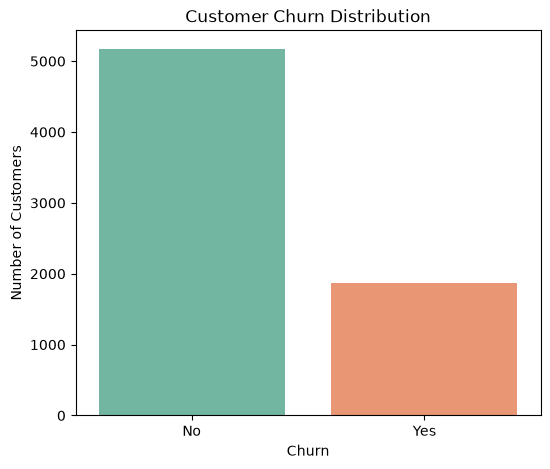

In [16]:
# Countplot of Target Variable (Churn)

plt.figure(figsize=(6,5))

sns.countplot(x="Churn", data=df, palette="Set2")

plt.title("Customer Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Number of Customers")

plt.show()

- The majority of customers belong to the **No Churn** category.


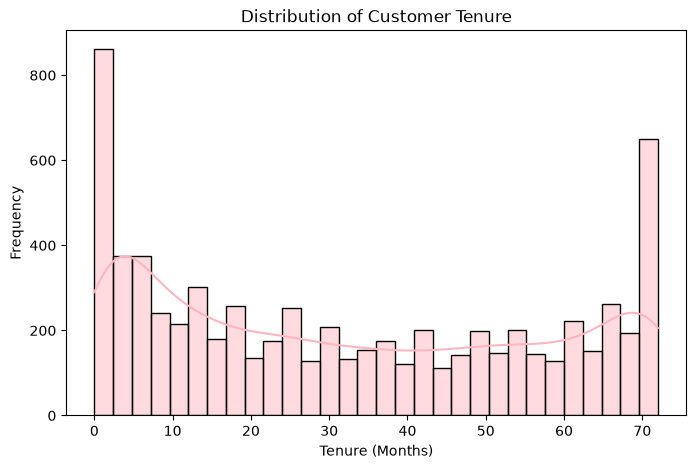

In [17]:
# Histogram of Tenure
plt.figure(figsize=(8,5))

sns.histplot(df["tenure"], bins=30, kde=True, color="lightpink")

plt.title("Distribution of Customer Tenure")
plt.xlabel("Tenure (Months)")
plt.ylabel("Frequency")

plt.show()

- The tenure distribution is not uniform.


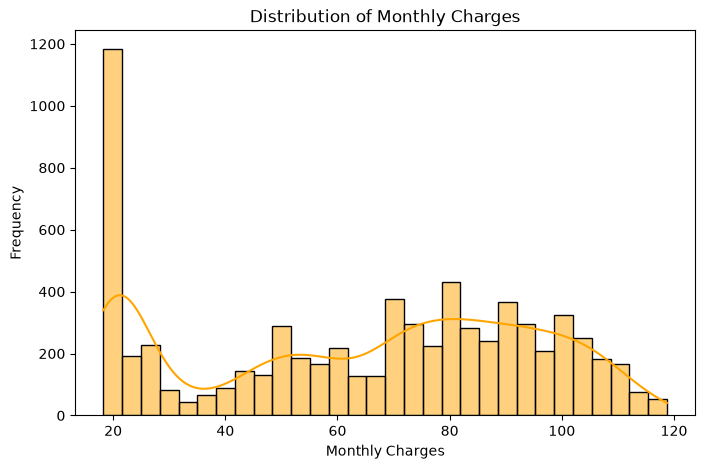

In [18]:
# Histogram of MonthlyCharges
plt.figure(figsize=(8,5))

sns.histplot(df["MonthlyCharges"], bins=30, kde=True, color="orange")

plt.title("Distribution of Monthly Charges")
plt.xlabel("Monthly Charges")
plt.ylabel("Frequency")

plt.show()

- Monthly charges range from low to high values.


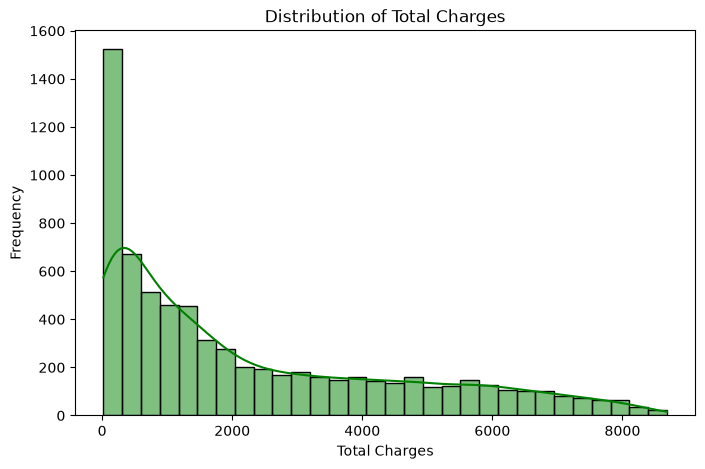

In [19]:
# Histogram of TotalCharges
plt.figure(figsize=(8,5))

sns.histplot(df["TotalCharges"], bins=30, kde=True, color="green")

plt.title("Distribution of Total Charges")
plt.xlabel("Total Charges")
plt.ylabel("Frequency")

plt.show()


- Total Charges show a right-skewed distribution.


C:\Users\Meet Anghan\AppData\Local\Temp\ipykernel_13540\2459709280.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x="Contract", data=df, palette="Set2")


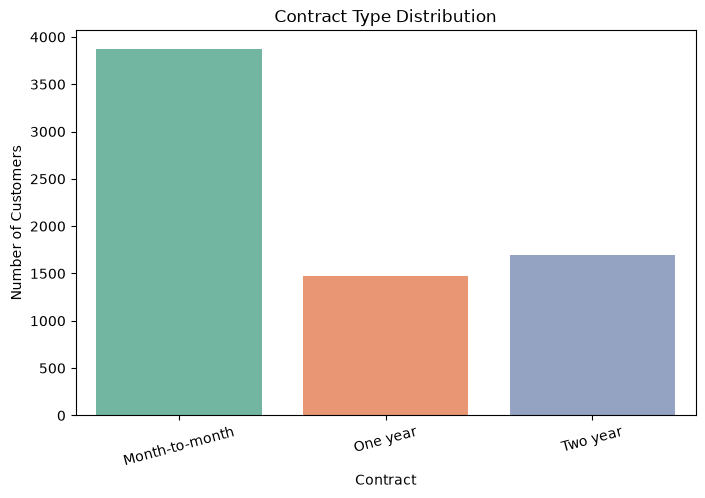

In [20]:
# Countplot of Contract
plt.figure(figsize=(8,5))

sns.countplot(x="Contract", data=df, palette="Set2")

plt.title("Contract Type Distribution")
plt.xlabel("Contract")
plt.ylabel("Number of Customers")

plt.xticks(rotation=15)

plt.show()

- **Month-to-Month** contracts are the most common.
- One-Year and Two-Year contracts have fewer customers.

C:\Users\Meet Anghan\AppData\Local\Temp\ipykernel_13540\4018725692.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x="InternetService", data=df, palette="Set3")


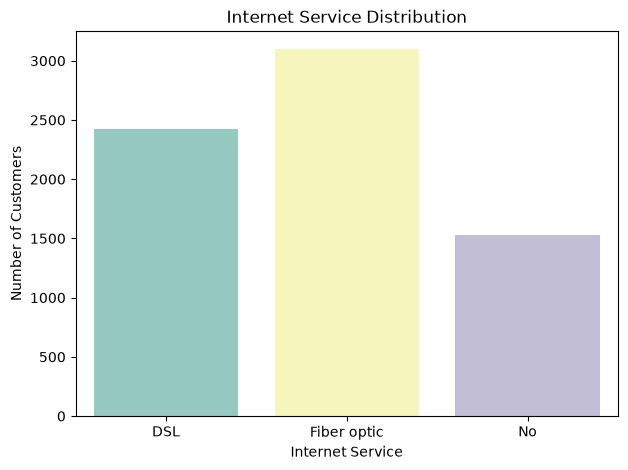

In [21]:
# Countplot of InternetService
plt.figure(figsize=(7,5))

sns.countplot(x="InternetService", data=df, palette="Set3")

plt.title("Internet Service Distribution")
plt.xlabel("Internet Service")
plt.ylabel("Number of Customers")

plt.show()

- Fiber Optic and DSL are the primary internet service types.


C:\Users\Meet Anghan\AppData\Local\Temp\ipykernel_13540\653494977.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x="PaymentMethod", data=df, palette="Pastel1")


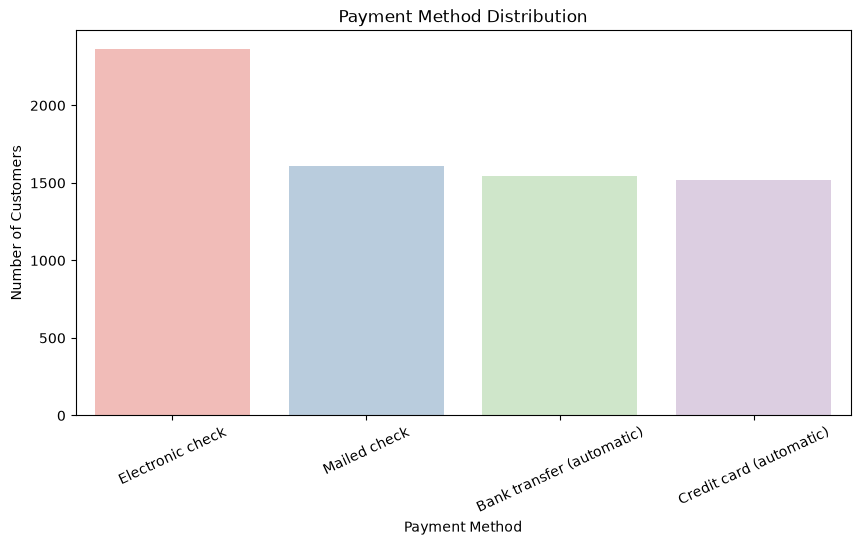

In [22]:
# Countplot of PaymentMethod
plt.figure(figsize=(10,5))

sns.countplot(x="PaymentMethod", data=df, palette="Pastel1")

plt.title("Payment Method Distribution")
plt.xlabel("Payment Method")
plt.ylabel("Number of Customers")

plt.xticks(rotation=25)

plt.show()

- Customers use multiple payment methods.
- Electronic Check appears to be one of the most frequently used payment methods.

## 2.3  Bivariate Analysis

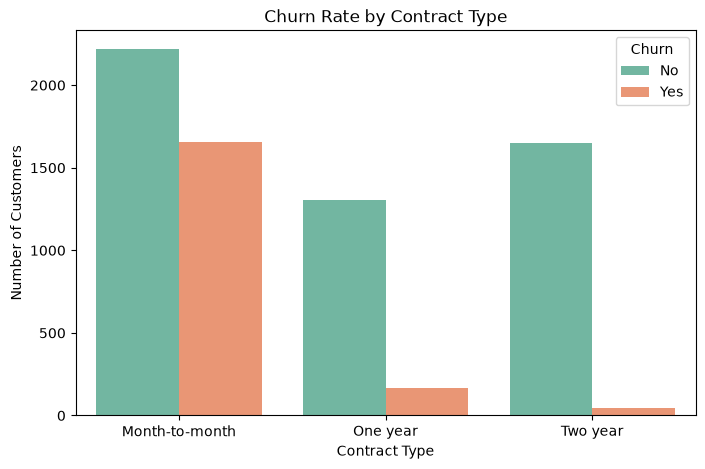

In [23]:
# Churn Rate by Contract Type (Grouped Bar Chart)
plt.figure(figsize=(8,5))

sns.countplot(x="Contract", hue="Churn", data=df, palette="Set2")

plt.title("Churn Rate by Contract Type")
plt.xlabel("Contract Type")
plt.ylabel("Number of Customers")

plt.show()

- Customers with **Month-to-Month** contracts have the highest churn rate.


In [24]:
# Create Tenure Buckets
bins = [0, 12, 24, 48, 72]
labels = ["0-12", "13-24", "25-48", "49-72"]

df["tenure_bucket"] = pd.cut(
    df["tenure"],
    bins=bins,
    labels=labels,
    include_lowest=True
)

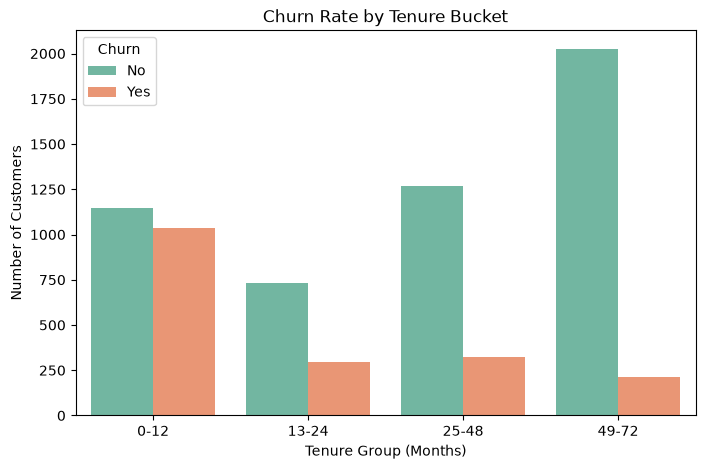

In [25]:
# Churn Rate by Tenure Bucket
plt.figure(figsize=(8,5))

sns.countplot(
    x="tenure_bucket",
    hue="Churn",
    data=df,
    palette="Set2"
)

plt.title("Churn Rate by Tenure Bucket")
plt.xlabel("Tenure Group (Months)")
plt.ylabel("Number of Customers")

plt.show()


- Customers with **0–12 months** tenure have the highest churn.

C:\Users\Meet Anghan\AppData\Local\Temp\ipykernel_13540\2326001171.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


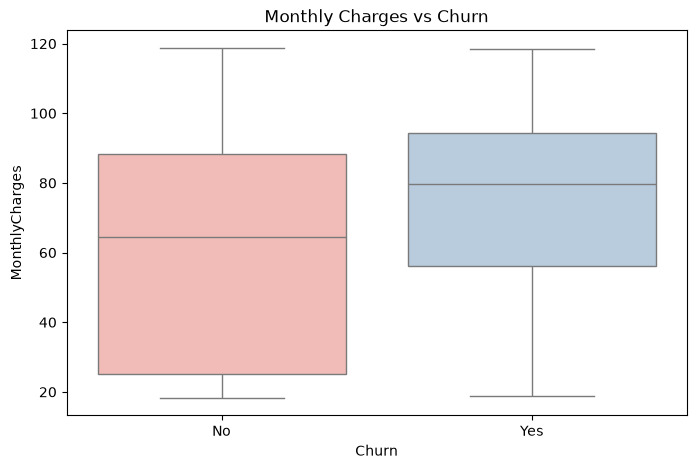

In [26]:
# Monthly Charges vs Churn (Boxplot)
plt.figure(figsize=(8,5))

sns.boxplot(
    x="Churn",
    y="MonthlyCharges",
    data=df,
    palette="Pastel1"
)

plt.title("Monthly Charges vs Churn")

plt.show()

- Customers who churn generally pay **higher monthly charges**.
- Higher monthly costs may increase customer dissatisfaction.
- Customers with expensive plans are more likely to switch providers.

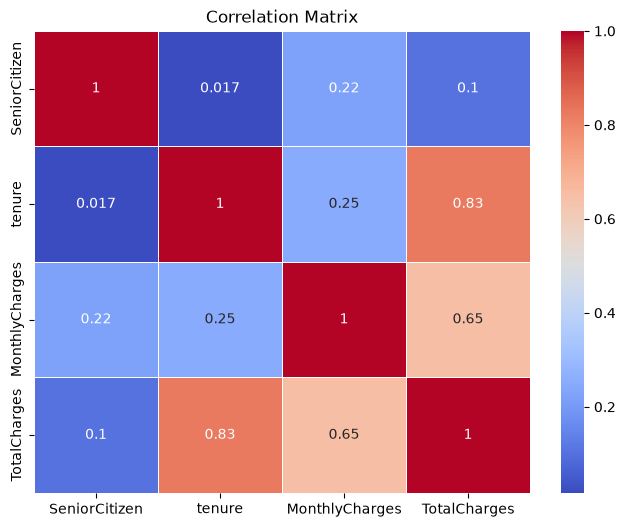

In [27]:
# Correlation Heatmap
numeric_df = df.select_dtypes(include=["int64", "float64"])

plt.figure(figsize=(8,6))

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap="coolwarm",
    linewidths=0.5
)

plt.title("Correlation Matrix")

plt.show()

## Key Business Insight

The exploratory data analysis confirms that:

- Customers with **Month-to-Month contracts** are the most likely to churn.
- Customers with **low tenure (0–12 months)** have the highest churn rate.
- Customers paying **higher Monthly Charges** are more likely to leave the company.
- Long-term contract customers show much better retention.

# Step 3: Data Preprocessing & Feature Engineering

## 3.1  Drop & Clean

In [28]:
# Drop customerID column
df.drop("customerID", axis=1, inplace=True)

df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,tenure_bucket
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No,0-12
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No,25-48
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,0-12
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No,25-48
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,0-12


In [29]:
# Check Missing Values
df.isnull().sum()

gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
tenure_bucket        0
dtype: int64

- Only the **TotalCharges** column previously contained missing values due to blank spaces.

In [30]:
# Fill Missing Values in TotalCharges
df["TotalCharges"].fillna(df["TotalCharges"].median(), inplace=True)

# Verify Missing Values
df.isnull().sum()

C:\Users\Meet Anghan\AppData\Local\Temp\ipykernel_13540\1369874363.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["TotalCharges"].fillna(df["TotalCharges"].median(), inplace=True)


gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
tenure_bucket       0
dtype: int64

- Missing values in the **TotalCharges** column have been replaced with the median value.


In [31]:
print("Shape after cleaning:", df.shape)

Shape after cleaning: (7043, 21)


## 3.2  Feature Engineering

In [32]:
# Create tenure_group
bins = [0, 12, 36, 60, np.inf]

labels = ["New", "Mid", "Senior", "Loyal"]

df["tenure_group"] = pd.cut(
    df["tenure"],
    bins=bins,
    labels=labels,
    include_lowest=True
)

df[["tenure", "tenure_group"]].head()

,tenure,tenure_group
0,1,New
1,34,Mid
2,2,New
3,45,Senior
4,2,New


- A new feature **tenure_group** has been created by grouping customers based on their tenure.
- Customers are classified as **New, Mid, Senior, and Loyal**.

In [33]:
# Create num_services
service_cols = [
    "OnlineSecurity",
    "OnlineBackup",
    "DeviceProtection",
    "TechSupport",
    "StreamingTV",
    "StreamingMovies"
]

df["num_services"] = (
    df[service_cols] == "Yes"
).sum(axis=1)

df[["num_services"]].head()

,num_services
0,1
1,2
2,2
3,3
4,0


- A new feature **num_services** counts the number of additional services subscribed by each customer.


In [34]:
# Create AutoPay
df["AutoPay"] = df["PaymentMethod"].str.contains(
    "automatic",
    case=False
).astype(int)

df[["PaymentMethod", "AutoPay"]].head()

,PaymentMethod,AutoPay
0,Electronic check,0
1,Mailed check,0
2,Mailed check,0
3,Bank transfer (automatic),1
4,Electronic check,0


- A new binary feature **AutoPay** has been created.
- Customers using automatic payment methods receive a value of **1**.

In [35]:
# Verify New Features
df[[
    "tenure",
    "tenure_group",
    "num_services",
    "PaymentMethod",
    "AutoPay"
]].head(10)

,tenure,tenure_group,num_services,PaymentMethod,AutoPay
0,1,New,1,Electronic check,0
1,34,Mid,2,Mailed check,0
2,2,New,2,Mailed check,0
3,45,Senior,3,Bank transfer (automatic),1
4,2,New,0,Electronic check,0
5,8,New,3,Electronic check,0
6,22,Mid,2,Credit card (automatic),1
7,10,New,1,Mailed check,0
8,28,Mid,4,Electronic check,0
9,62,Loyal,2,Bank transfer (automatic),1


- All engineered features have been successfully created.


In [36]:
print("Updated Shape:", df.shape)

Updated Shape: (7043, 24)


## 3.3  Encoding

In [38]:
# Binary Encoding
binary_cols = [
    "Partner",
    "Dependents",
    "PhoneService",
    "PaperlessBilling",
    "Churn"
]

for col in binary_cols:
    df[col] = df[col].map({
        "Yes": 1,
        "No": 0
    })

df[binary_cols].head()

,Partner,Dependents,PhoneService,PaperlessBilling,Churn
0,1,0,0,1,0
1,0,0,1,0,0
2,0,0,1,1,1
3,0,0,0,0,0
4,0,0,1,1,1


- Binary categorical features have been converted into numerical values.
- 'Yes' is encoded as **1** and 'No' as **0**.

In [39]:
# One-Hot Encoding
from sklearn.preprocessing import OneHotEncoder

ohe = OneHotEncoder(
    drop="first",
    sparse_output=False,
    handle_unknown="ignore"
)

encoded = ohe.fit_transform(
    df[["InternetService","Contract","PaymentMethod"]]
)

encoded_df = pd.DataFrame(
    encoded,
    columns=ohe.get_feature_names_out(
        ["InternetService","Contract","PaymentMethod"]
    ),
    index=df.index
)

df = pd.concat([df, encoded_df], axis=1)

df.drop(
    columns=[
        "InternetService",
        "Contract",
        "PaymentMethod"
    ],
    inplace=True
)

df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,PaperlessBilling,MonthlyCharges,TotalCharges,Churn,tenure_bucket,tenure_group,num_services,AutoPay,InternetService_Fiber optic,InternetService_No,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,Female,0,1,0,1,0,No phone service,No,Yes,No,No,No,No,1,29.85,29.85,0,0-12,New,1,0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
1,Male,0,0,0,34,1,No,Yes,No,Yes,No,No,No,0,56.95,1889.50,0,25-48,Mid,2,0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
2,Male,0,0,0,2,1,No,Yes,Yes,No,No,No,No,1,53.85,108.15,1,0-12,New,2,0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
3,Male,0,0,0,45,0,No phone service,Yes,No,Yes,Yes,No,No,0,42.30,1840.75,0,25-48,Senior,3,1,0.0,0.0,1.0,0.0,0.0,0.0,0.0
4,Female,0,0,0,2,1,No,No,No,No,No,No,No,1,70.70,151.65,1,0-12,New,0,0,1.0,0.0,0.0,0.0,0.0,1.0,0.0


- One-Hot Encoding converts categorical variables into multiple binary columns.
- The first category is dropped to avoid the dummy variable trap.

In [40]:
# Apply Label Encoding to: tenure_group (preserving ordinal order).

from sklearn.preprocessing import OrdinalEncoder

oe = OrdinalEncoder(
    categories=[["New","Mid","Senior","Loyal"]]
)

df[["tenure_group"]] = oe.fit_transform(
    df[["tenure_group"]]
)

df["tenure_group"] = df["tenure_group"].astype(int)

df[["tenure_group"]].head()

,tenure_group
0,0
1,1
2,0
3,2
4,0


- tenure_group has been encoded while preserving its natural order.
- The encoded order is:
  - New = 0
  - Mid = 1
  - Senior = 2
  - Loyal = 3

## Step 3.4 Scaling

In [43]:
# Encode Remaining Object Columns
remaining_cols = [
    "gender",
    "MultipleLines",
    "OnlineSecurity",
    "OnlineBackup",
    "DeviceProtection",
    "TechSupport",
    "StreamingTV",
    "StreamingMovies",
    "tenure_bucket"
]

df = pd.get_dummies(
    df,
    columns=remaining_cols,
    drop_first=True,
    dtype=int
)

df.head()

,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,Churn,tenure_group,num_services,AutoPay,InternetService_Fiber optic,InternetService_No,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,gender_Male,MultipleLines_No phone service,MultipleLines_Yes,OnlineSecurity_No internet service,OnlineSecurity_Yes,OnlineBackup_No internet service,OnlineBackup_Yes,DeviceProtection_No internet service,DeviceProtection_Yes,TechSupport_No internet service,TechSupport_Yes,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,tenure_bucket_13-24,tenure_bucket_25-48,tenure_bucket_49-72
0,0,1,0,1,0,1,29.85,29.85,0,0,1,0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0,1,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0
1,0,0,0,34,1,0,56.95,1889.50,0,1,2,0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,1,0,0,0,1,0,0,0,1,0,0,0,0,0,0,0,1,0
2,0,0,0,2,1,1,53.85,108.15,1,0,2,0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1,0,0,0,1,0,1,0,0,0,0,0,0,0,0,0,0,0
3,0,0,0,45,0,0,42.30,1840.75,0,2,3,1,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1,1,0,0,1,0,0,0,1,0,1,0,0,0,0,0,1,0
4,0,0,0,2,1,1,70.70,151.65,1,0,0,0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


In [44]:
# Apply StandardScaler
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

scale_cols = [
    "tenure",
    "MonthlyCharges",
    "TotalCharges",
    "num_services"
]

df[scale_cols] = scaler.fit_transform(df[scale_cols])

df.head()

,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,Churn,tenure_group,num_services,AutoPay,InternetService_Fiber optic,InternetService_No,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,gender_Male,MultipleLines_No phone service,MultipleLines_Yes,OnlineSecurity_No internet service,OnlineSecurity_Yes,OnlineBackup_No internet service,OnlineBackup_Yes,DeviceProtection_No internet service,DeviceProtection_Yes,TechSupport_No internet service,TechSupport_Yes,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,tenure_bucket_13-24,tenure_bucket_25-48,tenure_bucket_49-72
0,0,1,0,-1.277445,0,1,-1.160323,-0.994242,0,0,-0.561776,0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0,1,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0.066327,1,0,-0.259629,-0.173244,0,1,-0.020519,0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,1,0,0,0,1,0,0,0,1,0,0,0,0,0,0,0,1,0
2,0,0,0,-1.236724,1,1,-0.362660,-0.959674,1,0,-0.020519,0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1,0,0,0,1,0,1,0,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0.514251,0,0,-0.746535,-0.194766,0,2,0.520738,1,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1,1,0,0,1,0,0,0,1,0,1,0,0,0,0,0,1,0
4,0,0,0,-1.236724,1,1,0.197365,-0.940470,1,0,-1.103033,0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


- StandardScaler standardizes numerical features by removing the mean and scaling to unit variance.


## 3.6  Train-Test Split

In [46]:
from sklearn.model_selection import train_test_split

# Features and Target
X = df.drop("Churn", axis=1)
y = df["Churn"]

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("X_train Shape :", X_train.shape)
print("X_test Shape  :", X_test.shape)
print("y_train Shape :", y_train.shape)
print("y_test Shape  :", y_test.shape)

X_train Shape : (5634, 36)
X_test Shape  : (1409, 36)
y_train Shape : (5634,)
y_test Shape  : (1409,)


- The dataset has been split into **80% training** and **20% testing** sets.


## 3.5  Handle Class Imbalance


In [47]:
print("Before SMOTE")
print(y_train.value_counts())

Before SMOTE
Churn
0    4139
1    1495
Name: count, dtype: int64


In [ ]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train,
    y_train
)

print("After SMOTE")
print(y_train_smote.value_counts())

After SMOTE
Churn
0    4139
1    4139
Name: count, dtype: int64


- Before applying SMOTE, the training dataset was imbalanced.
- SMOTE generated synthetic samples for the minority (Churn) class.

# Step 4: Model Building — KNN & Naive Bayes

## 4.1  K-Nearest Neighbours (KNN)


In [51]:
# KNN Baseline (k = 5)
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

knn = KNeighborsClassifier(n_neighbors=5)

knn.fit(X_train_smote, y_train_smote)

y_pred = knn.predict(X_test)
y_prob = knn.predict_proba(X_test)[:,1]

print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision :", precision_score(y_test, y_pred))
print("Recall :", recall_score(y_test, y_pred))
print("F1-Score :", f1_score(y_test, y_pred))
print("ROC-AUC :", roc_auc_score(y_test, y_prob))

print("\nClassification Report\n")
print(classification_report(y_test, y_pred))

Accuracy : 0.7061745919091554
Precision : 0.4647887323943662
Recall : 0.7058823529411765
F1-Score : 0.5605095541401274
ROC-AUC : 0.7717597974631223

Classification Report

              precision    recall  f1-score   support

           0       0.87      0.71      0.78      1035
           1       0.46      0.71      0.56       374

    accuracy                           0.71      1409
   macro avg       0.67      0.71      0.67      1409
weighted avg       0.76      0.71      0.72      1409



- The baseline KNN model was trained using **k = 5**.
- The model performance was evaluated using Accuracy, Precision, Recall, F1-Score, and ROC-AUC.

In [53]:
# Tune k (1,3,5,7,9,11,15)
k_values = [1,3,5,7,9,11,15]

f1_scores = []

for k in k_values:

    model = KNeighborsClassifier(n_neighbors=k)

    model.fit(X_train_smote, y_train_smote)

    pred = model.predict(X_test)

    score = f1_score(y_test, pred)

    f1_scores.append(score)

result = pd.DataFrame({
    "K": k_values,
    "F1 Score": f1_scores
})

result

,K,F1 Score
0,1,0.504142
1,3,0.553145
2,5,0.560510
3,7,0.579381
4,9,0.585170
5,11,0.586275
6,15,0.590291


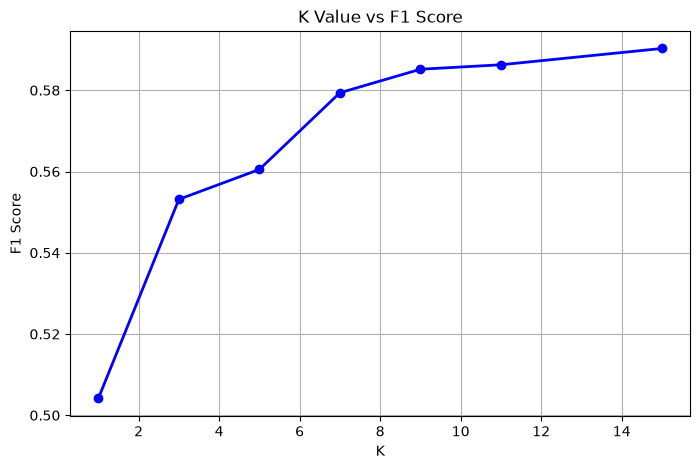

In [60]:
# Plot K vs F1 Score
plt.figure(figsize=(8,5))

plt.plot(k_values,
         f1_scores,
         marker="o",
         linewidth=2,
         color="blue")

plt.title("K Value vs F1 Score")
plt.xlabel("K")
plt.ylabel("F1 Score")

plt.grid(True)

plt.show()

In [61]:
# Best K
best_k = result.loc[result["F1 Score"].idxmax(),"K"]

print("Best K :", best_k)

Best K : 15


In [62]:
# Retrain using Best K
best_knn = KNeighborsClassifier(n_neighbors=best_k)

best_knn.fit(X_train_smote, y_train_smote)

y_pred_best = best_knn.predict(X_test)

y_prob_best = best_knn.predict_proba(X_test)[:,1]

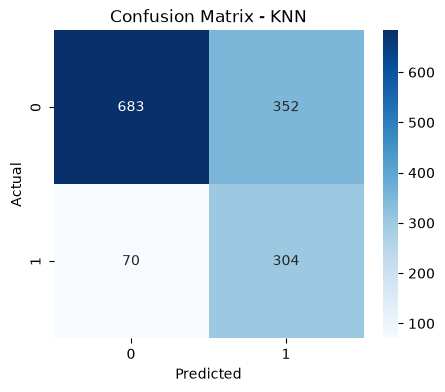

In [63]:
# Confusion Matrix
cm = confusion_matrix(y_test,y_pred_best)

plt.figure(figsize=(5,4))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - KNN")

plt.show()

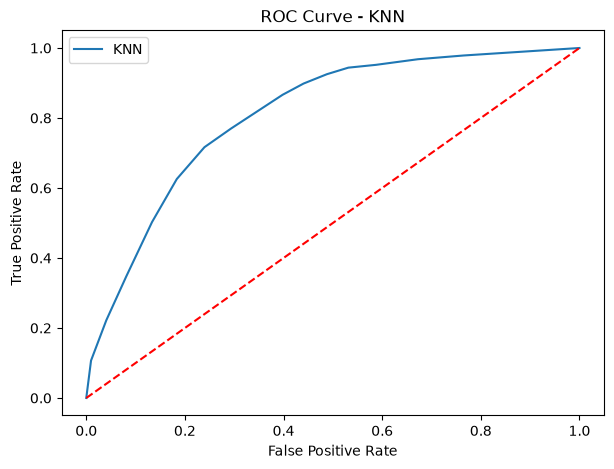

ROC-AUC : 0.8094667906688366


In [64]:
# ROC Curve
from sklearn.metrics import roc_curve

fpr, tpr, threshold = roc_curve(y_test, y_prob_best)

plt.figure(figsize=(7,5))

plt.plot(fpr, tpr, label="KNN")

plt.plot([0,1],[0,1],"r--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - KNN")

plt.legend()

plt.show()

print("ROC-AUC :", roc_auc_score(y_test, y_prob_best))

- The ROC curve evaluates the model's ability to distinguish churn and non-churn customers.
- A higher ROC-AUC value indicates better classification performance.

## 4.2  Naive Bayes — Gaussian NB

In [65]:
# Train Gaussian Naive Bayes
from sklearn.naive_bayes import GaussianNB

nb = GaussianNB()

nb.fit(X_train_smote, y_train_smote)

y_pred_nb = nb.predict(X_test)
y_prob_nb = nb.predict_proba(X_test)[:,1]

print("Accuracy :", accuracy_score(y_test, y_pred_nb))
print("Precision :", precision_score(y_test, y_pred_nb))
print("Recall :", recall_score(y_test, y_pred_nb))
print("F1 Score :", f1_score(y_test, y_pred_nb))
print("ROC-AUC :", roc_auc_score(y_test, y_prob_nb))

print("\nClassification Report\n")
print(classification_report(y_test, y_pred_nb))

Accuracy : 0.6919801277501775
Precision : 0.4557522123893805
Recall : 0.8262032085561497
F1 Score : 0.5874524714828897
ROC-AUC : 0.8107675217649642

Classification Report

              precision    recall  f1-score   support

           0       0.91      0.64      0.75      1035
           1       0.46      0.83      0.59       374

    accuracy                           0.69      1409
   macro avg       0.68      0.73      0.67      1409
weighted avg       0.79      0.69      0.71      1409



- Gaussian Naive Bayes was trained using default parameters.
- The model performance was evaluated using Accuracy, Precision, Recall, F1-Score, and ROC-AUC.
- Recall is particularly important because failing to identify churn customers can lead to customer loss.

In [66]:
print("Class Prior Probabilities :")

print(nb.class_prior_)

Class Prior Probabilities :
[0.5 0.5]


- The class_prior_ attribute shows the prior probability learned for each class.
- Since SMOTE was applied, both classes are nearly balanced.
- Therefore, the learned prior probabilities are approximately equal and do not match the original dataset's churn distribution.

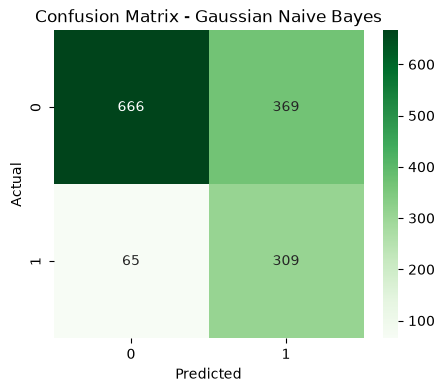

In [67]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_nb)

plt.figure(figsize=(5,4))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Greens"
)

plt.title("Confusion Matrix - Gaussian Naive Bayes")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()

- The confusion matrix displays correct and incorrect classifications.
- False Negatives are important because they represent churn customers that were not identified.
- A lower number of False Negatives indicates better churn detection.

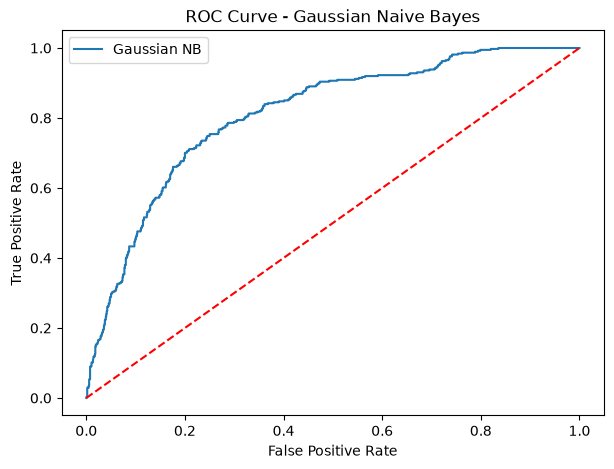

ROC-AUC : 0.8107675217649642


In [68]:
# ROC Curve
fpr, tpr, threshold = roc_curve(y_test, y_prob_nb)

plt.figure(figsize=(7,5))

plt.plot(
    fpr,
    tpr,
    label="Gaussian NB"
)

plt.plot(
    [0,1],
    [0,1],
    "r--"
)

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title("ROC Curve - Gaussian Naive Bayes")

plt.legend()

plt.show()

print("ROC-AUC :", roc_auc_score(y_test, y_prob_nb))

- The ROC curve illustrates the classification performance of the Gaussian Naive Bayes model.
- A higher ROC-AUC value indicates better discrimination between churn and non-churn customers.

### Does the Feature Independence Assumption Hold?

- Gaussian Naive Bayes assumes that all input features are independent of each other.
- In the Telco Customer Churn dataset, several features such as **Tenure, TotalCharges, and MonthlyCharges** are correlated.
- Therefore, the independence assumption is not completely satisfied.
- Despite this limitation, Gaussian Naive Bayes still provides a fast and effective baseline classification model.

# Step 5: Model Building — SVM & Decision Tree

## 5.1  Support Vector Machine (SVM)

In [69]:
# Train SVM
from sklearn.svm import SVC

svm = SVC(
    kernel='rbf',
    C=1,
    gamma='scale',
    probability=True,
    random_state=42
)

svm.fit(X_train_smote, y_train_smote)

y_pred_svm = svm.predict(X_test)
y_prob_svm = svm.predict_proba(X_test)[:,1]

print("Accuracy :", accuracy_score(y_test, y_pred_svm))
print("Precision :", precision_score(y_test, y_pred_svm))
print("Recall :", recall_score(y_test, y_pred_svm))
print("F1 Score :", f1_score(y_test, y_pred_svm))
print("ROC-AUC :", roc_auc_score(y_test, y_prob_svm))

print("\nClassification Report\n")
print(classification_report(y_test, y_pred_svm))


Accuracy : 0.7686302342086586
Precision : 0.5504201680672269
Recall : 0.7005347593582888
F1 Score : 0.6164705882352941
ROC-AUC : 0.8225244775116897

Classification Report

              precision    recall  f1-score   support

           0       0.88      0.79      0.83      1035
           1       0.55      0.70      0.62       374

    accuracy                           0.77      1409
   macro avg       0.72      0.75      0.73      1409
weighted avg       0.79      0.77      0.78      1409



- The SVM model has been trained using the RBF kernel.
- Model performance is evaluated using Accuracy, Precision, Recall, F1-Score and ROC-AUC.
- Recall is an important metric because detecting churn customers is the main business objective.

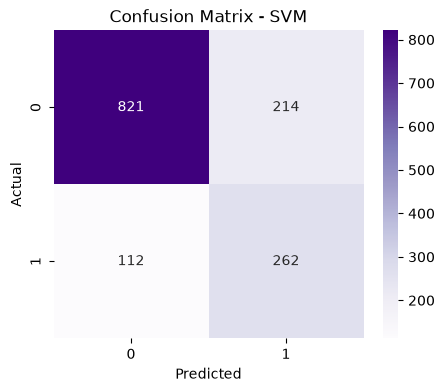

In [70]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_svm)

plt.figure(figsize=(5,4))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Purples"
)

plt.title("Confusion Matrix - SVM")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

- The confusion matrix shows correct and incorrect classifications.
- A lower number of False Negatives means the model successfully identifies more churn customers.

In [71]:
# Tune C using Cross Validation
from sklearn.model_selection import cross_val_score

C_values = [0.1, 1, 10, 100]

f1_scores = []

for c in C_values:

    model = SVC(
        kernel="rbf",
        C=c,
        gamma="scale",
        probability=True,
        random_state=42
    )

    score = cross_val_score(
        model,
        X_train_smote,
        y_train_smote,
        cv=3,
        scoring="f1"
    )

    f1_scores.append(score.mean())

result = pd.DataFrame({
    "C Value": C_values,
    "Mean F1 Score": f1_scores
})

result

,C Value,Mean F1 Score
0,0.1,0.778739
1,1.0,0.793933
2,10.0,0.809062
3,100.0,0.806612


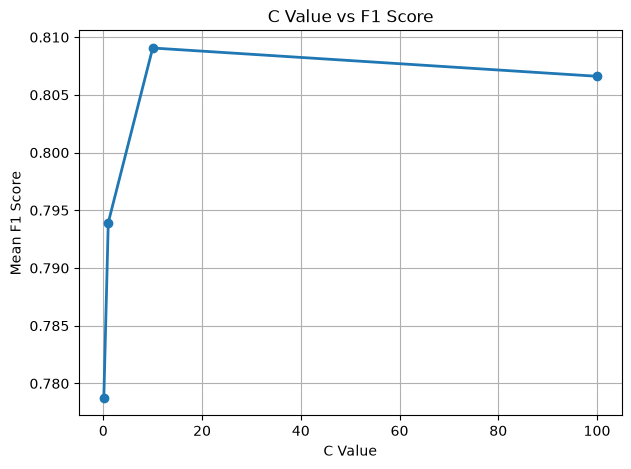

In [72]:
# Plot C vs F1 Score
plt.figure(figsize=(7,5))

plt.plot(
    C_values,
    f1_scores,
    marker="o",
    linewidth=2
)

plt.title("C Value vs F1 Score")
plt.xlabel("C Value")
plt.ylabel("Mean F1 Score")

plt.grid(True)

plt.show()

In [73]:
# Best C
best_c = result.loc[
    result["Mean F1 Score"].idxmax(),
    "C Value"
]

print("Best C :", best_c)

Best C : 10.0


In [74]:
# Retrain with Best C
best_svm = SVC(
    kernel="rbf",
    C=best_c,
    gamma="scale",
    probability=True,
    random_state=42
)

best_svm.fit(X_train_smote, y_train_smote)

y_pred_best_svm = best_svm.predict(X_test)

y_prob_best_svm = best_svm.predict_proba(X_test)[:,1]

In [75]:
# Final Metrics
print("Accuracy :", accuracy_score(y_test, y_pred_best_svm))
print("Precision :", precision_score(y_test, y_pred_best_svm))
print("Recall :", recall_score(y_test, y_pred_best_svm))
print("F1 Score :", f1_score(y_test, y_pred_best_svm))
print("ROC-AUC :", roc_auc_score(y_test, y_prob_best_svm))

Accuracy : 0.7622427253371186
Precision : 0.5421166306695464
Recall : 0.6711229946524064
F1 Score : 0.5997610513739546
ROC-AUC : 0.8087266527164225


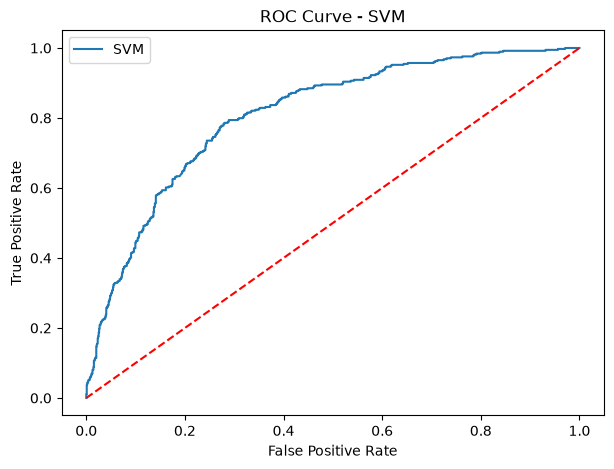

In [76]:
# ROC Curve

fpr, tpr, threshold = roc_curve(
    y_test,
    y_prob_best_svm
)

plt.figure(figsize=(7,5))

plt.plot(
    fpr,
    tpr,
    label="SVM"
)

plt.plot(
    [0,1],
    [0,1],
    "r--"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("ROC Curve - SVM")

plt.legend()

plt.show()

- The ROC curve illustrates the model's ability to distinguish between churn and non-churn customers.
- A higher ROC-AUC score indicates better classification performance.

## Business Trade-off: Interpretability vs Performance

- SVM generally provides high prediction accuracy but is considered a black-box model because its decision-making process is difficult to interpret.
- Although business managers may prefer interpretable models like Decision Trees, SVM is often selected when prediction performance is the primary objective.

## 5.2  Decision Tree Classifier

In [77]:
# Train Decision Tree
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(
    max_depth=5,
    class_weight="balanced",
    random_state=42
)

dt.fit(X_train_smote, y_train_smote)

y_pred_dt = dt.predict(X_test)
y_prob_dt = dt.predict_proba(X_test)[:,1]

print("Accuracy :", accuracy_score(y_test, y_pred_dt))
print("Precision :", precision_score(y_test, y_pred_dt))
print("Recall :", recall_score(y_test, y_pred_dt))
print("F1 Score :", f1_score(y_test, y_pred_dt))
print("ROC-AUC :", roc_auc_score(y_test, y_prob_dt))

print("\nClassification Report\n")
print(classification_report(y_test, y_pred_dt))

Accuracy : 0.7381121362668559
Precision : 0.5043936731107206
Recall : 0.767379679144385
F1 Score : 0.6086956521739131
ROC-AUC : 0.8196840528042574

Classification Report

              precision    recall  f1-score   support

           0       0.90      0.73      0.80      1035
           1       0.50      0.77      0.61       374

    accuracy                           0.74      1409
   macro avg       0.70      0.75      0.71      1409
weighted avg       0.79      0.74      0.75      1409



- The Decision Tree model was trained using a maximum depth of 5.
- Class balancing was applied using `class_weight='balanced'`.
- The model performance is evaluated using Accuracy, Precision, Recall, F1-Score, and ROC-AUC.

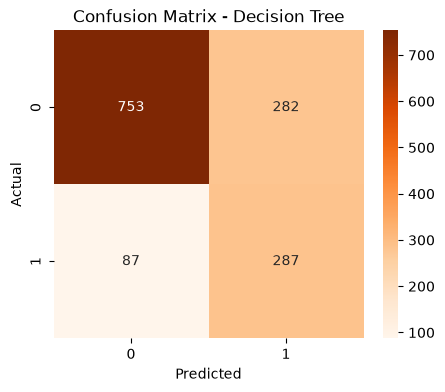

In [78]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_dt)

plt.figure(figsize=(5,4))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Oranges"
)

plt.title("Confusion Matrix - Decision Tree")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

- The confusion matrix shows the model's correct and incorrect predictions.
- Lower False Negatives indicate better identification of churn customers.

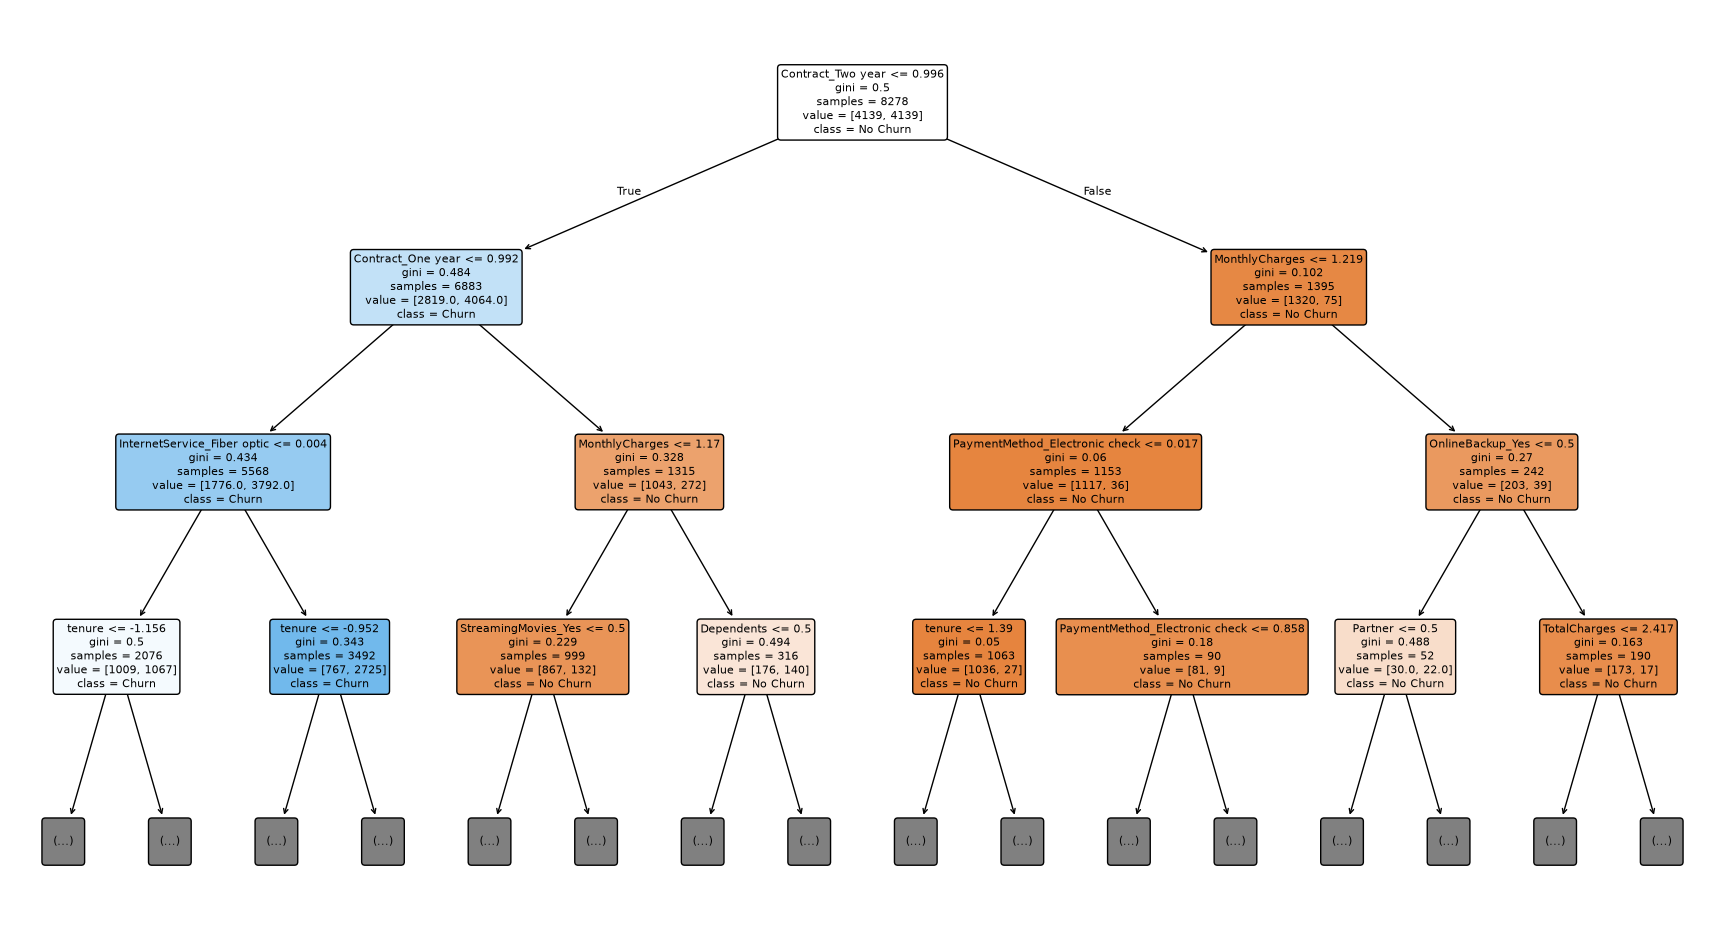

In [79]:
# Visualize Decision Tree
from sklearn.tree import plot_tree

plt.figure(figsize=(22,12))

plot_tree(
    dt,
    feature_names=X_train.columns,
    class_names=["No Churn","Churn"],
    filled=True,
    rounded=True,
    max_depth=3,
    fontsize=8
)

plt.show()

In [81]:
# Root Split Feature 
print("Root Split Feature :")

print(X_train.columns[dt.tree_.feature[0]])

Root Split Feature :
Contract_Two year


- The root node represents the most important feature used for the first split.
- This feature has the highest influence on predicting customer churn.

In [83]:
# Tune Max Depth
depths = [3,4,5,6,7,8,None]

scores = []

for depth in depths:

    model = DecisionTreeClassifier(
        max_depth=depth,
        class_weight="balanced",
        random_state=42
    )

    score = cross_val_score(
        model,
        X_train_smote,
        y_train_smote,
        cv=3,
        scoring="f1"
    )

    scores.append(score.mean())

result = pd.DataFrame({
    "Depth":depths,
    "Mean F1":scores
})

result

,Depth,Mean F1
0,3.0,0.781537
1,4.0,0.783420
2,5.0,0.786637
3,6.0,0.788311
4,7.0,0.789774
5,8.0,0.800264
6,NaN,0.783422


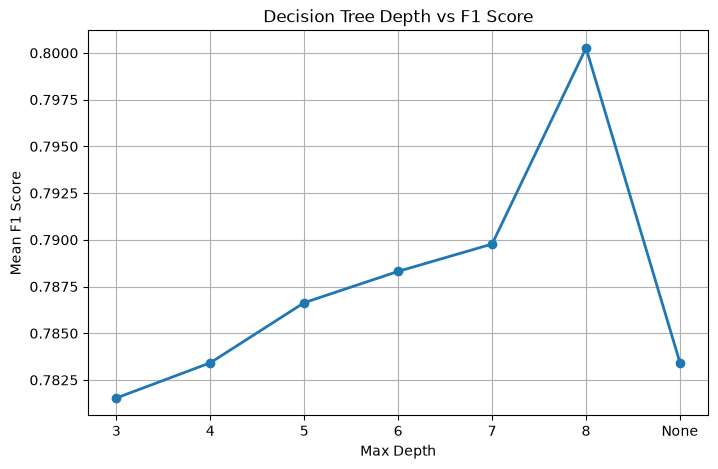

In [84]:
# Plot Depth vs F1
plt.figure(figsize=(8,5))

labels = ["3","4","5","6","7","8","None"]

plt.plot(
    labels,
    scores,
    marker="o",
    linewidth=2
)

plt.title("Decision Tree Depth vs F1 Score")

plt.xlabel("Max Depth")

plt.ylabel("Mean F1 Score")

plt.grid(True)

plt.show()

In [85]:
# Best Depth
best_depth = result.loc[
    result["Mean F1"].idxmax(),
    "Depth"
]

print("Best Depth :", best_depth)

Best Depth : 8.0


In [ ]:
# Retrain with Best Depth

best_depth = int(best_depth)

best_dt = DecisionTreeClassifier(
    max_depth=best_depth,
    class_weight="balanced",
    random_state=42
)

best_dt.fit(
    X_train_smote,
    y_train_smote
)

y_pred_best_dt = best_dt.predict(X_test)

In [89]:
# Feature Importance
importance = pd.DataFrame({
    "Feature":X_train.columns,
    "Importance":best_dt.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

top15 = importance.head(15)

top15

,Feature,Importance
14,Contract_Two year,0.320210
13,Contract_One year,0.250395
3,tenure,0.111777
11,InternetService_Fiber optic,0.089231
6,MonthlyCharges,0.054586
16,PaymentMethod_Electronic check,0.024523
7,TotalCharges,0.020664
22,OnlineSecurity_Yes,0.015909
4,PhoneService,0.011842
28,TechSupport_Yes,0.011631


C:\Users\Meet Anghan\AppData\Local\Temp\ipykernel_13540\2428566427.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


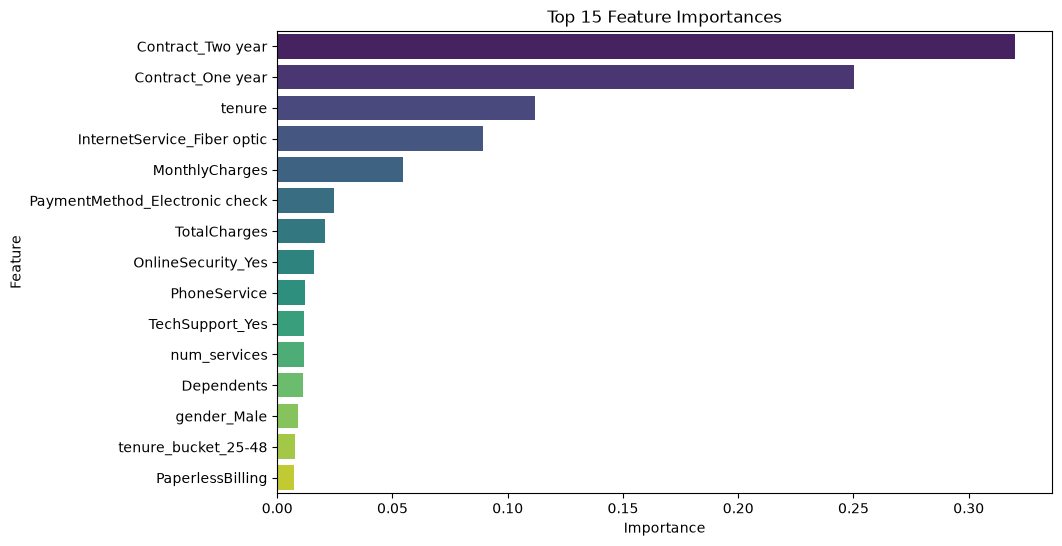

In [90]:
# Plot Top 15 Features
plt.figure(figsize=(10,6))

sns.barplot(
    data=top15,
    x="Importance",
    y="Feature",
    palette="viridis"
)

plt.title("Top 15 Feature Importances")

plt.show()

- The bar chart displays the 15 most important features used by the Decision Tree.
- Features with higher importance contribute more to churn prediction.
- These features can help the business understand the key factors influencing customer churn.

## 5.3  One Model with class_weight='balanced' vs SMOTE

In [91]:
# Decision Tree with SMOTE
dt_smote = DecisionTreeClassifier(
    max_depth=best_depth,
    random_state=42
)

dt_smote.fit(X_train_smote, y_train_smote)

y_pred_smote = dt_smote.predict(X_test)

recall_smote = recall_score(y_test, y_pred_smote)

print("Recall (SMOTE) :", recall_smote)

Recall (SMOTE) : 0.7219251336898396


In [92]:
# Decision Tree with class_weight='balanced'
dt_balanced = DecisionTreeClassifier(
    max_depth=best_depth,
    class_weight="balanced",
    random_state=42
)

dt_balanced.fit(X_train, y_train)

y_pred_balanced = dt_balanced.predict(X_test)

recall_balanced = recall_score(y_test, y_pred_balanced)

print("Recall (Class Weight) :", recall_balanced)

Recall (Class Weight) : 0.7486631016042781


In [93]:
# Compare Recall
comparison = pd.DataFrame({
    "Method": ["SMOTE", "Class Weight"],
    "Recall": [recall_smote, recall_balanced]
})

comparison

,Method,Recall
0,SMOTE,0.721925
1,Class Weight,0.748663


C:\Users\Meet Anghan\AppData\Local\Temp\ipykernel_13540\3651322369.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


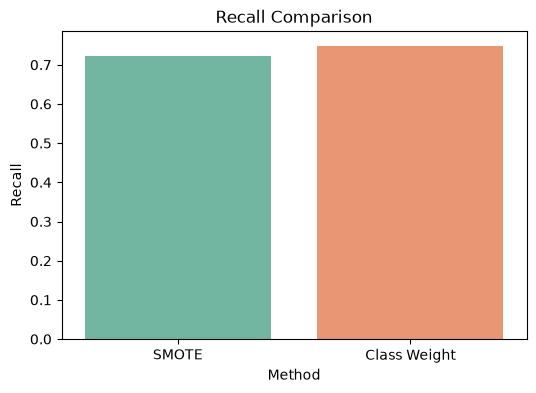

In [94]:
plt.figure(figsize=(6,4))

sns.barplot(
    data=comparison,
    x="Method",
    y="Recall",
    palette="Set2"
)

plt.title("Recall Comparison")
plt.ylabel("Recall")

plt.show()

In [95]:
# best method
if recall_smote > recall_balanced:
    print("SMOTE provides better Recall.")
elif recall_balanced > recall_smote:
    print("Class Weight provides better Recall.")
else:
    print("Both methods provide the same Recall.")

Class Weight provides better Recall.


# Step 6: Model Evaluation & Comparison

In [96]:
# Model Comparison Table

dt_prob = best_dt.predict_proba(X_test)[:,1]

comparison = pd.DataFrame({

    "Model":[
        "KNN",
        "Naive Bayes",
        "SVM",
        "Decision Tree"
    ],

    "Accuracy":[
        accuracy_score(y_test,y_pred_best),
        accuracy_score(y_test,y_pred_nb),
        accuracy_score(y_test,y_pred_best_svm),
        accuracy_score(y_test,y_pred_best_dt)
    ],

    "Precision":[
        precision_score(y_test,y_pred_best),
        precision_score(y_test,y_pred_nb),
        precision_score(y_test,y_pred_best_svm),
        precision_score(y_test,y_pred_best_dt)
    ],

    "Recall":[
        recall_score(y_test,y_pred_best),
        recall_score(y_test,y_pred_nb),
        recall_score(y_test,y_pred_best_svm),
        recall_score(y_test,y_pred_best_dt)
    ],

    "F1 Score":[
        f1_score(y_test,y_pred_best),
        f1_score(y_test,y_pred_nb),
        f1_score(y_test,y_pred_best_svm),
        f1_score(y_test,y_pred_best_dt)
    ],

    "ROC AUC":[
        roc_auc_score(y_test,y_prob_best),
        roc_auc_score(y_test,y_prob_nb),
        roc_auc_score(y_test,y_prob_best_svm),
        roc_auc_score(y_test,dt_prob)
    ]

})

comparison = comparison.sort_values(
    by="Recall",
    ascending=False
)

comparison

,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC
1,Naive Bayes,0.691980,0.455752,0.826203,0.587452,0.810768
0,KNN,0.700497,0.463415,0.812834,0.590291,0.809467
3,Decision Tree,0.750887,0.522244,0.721925,0.606061,0.806509
2,SVM,0.762243,0.542117,0.671123,0.599761,0.808727


In [98]:
# KNN Training Time
import time

start = time.time()

best_knn = KNeighborsClassifier(n_neighbors=best_k)

best_knn.fit(X_train_smote, y_train_smote)

knn_time = time.time() - start

print("Training Time :", knn_time, "seconds")

Training Time : 0.015425682067871094 seconds


In [99]:
# Gaussian Naive Bayes Training Time
start = time.time()

gnb = GaussianNB()

gnb.fit(X_train_smote, y_train_smote)

nb_time = time.time() - start

print("Training Time :", nb_time, "seconds")

Training Time : 0.029137134552001953 seconds


In [100]:
# SVM Training Time

start = time.time()

best_svm = SVC(
    kernel="rbf",
    C=best_c,
    gamma="scale",
    probability=True,
    random_state=42
)

best_svm.fit(X_train_smote, y_train_smote)

svm_time = time.time() - start

print("Training Time :", svm_time, "seconds")

Training Time : 39.75301456451416 seconds


In [101]:
# Decision Tree Training Time
start = time.time()

best_dt.fit(X_train_smote, y_train_smote)

dt_time = time.time() - start

print("Decision Tree Training Time :", round(dt_time, 4), "seconds")

Decision Tree Training Time : 0.1678 seconds


In [102]:
# Model Comparison Table with Training Time
comparison["Training Time (Sec)"] = [
    knn_time,
    nb_time,
    svm_time,
    dt_time
]

comparison

,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC,Training Time (Sec)
1,Naive Bayes,0.691980,0.455752,0.826203,0.587452,0.810768,0.015426
0,KNN,0.700497,0.463415,0.812834,0.590291,0.809467,0.029137
3,Decision Tree,0.750887,0.522244,0.721925,0.606061,0.806509,39.753015
2,SVM,0.762243,0.542117,0.671123,0.599761,0.808727,0.167834


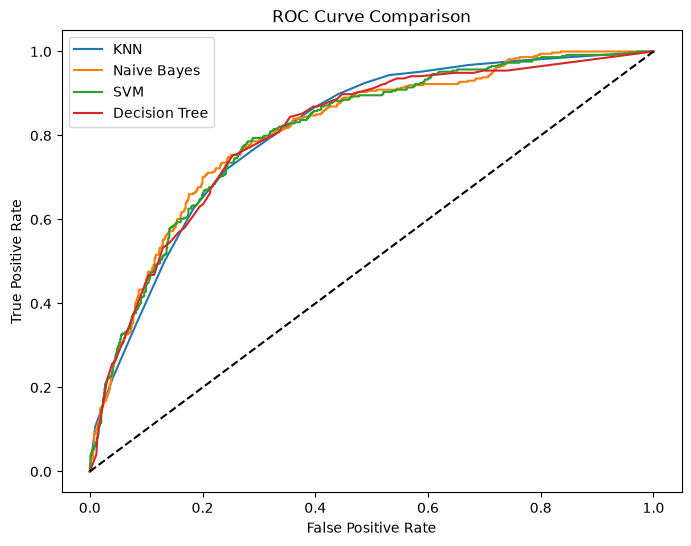

In [103]:
# ROC Curve (All Models)
plt.figure(figsize=(8,6))

# KNN
fpr,tpr,_=roc_curve(y_test,y_prob_best)
plt.plot(fpr,tpr,label="KNN")

# NB
fpr,tpr,_=roc_curve(y_test,y_prob_nb)
plt.plot(fpr,tpr,label="Naive Bayes")

# SVM
fpr,tpr,_=roc_curve(y_test,y_prob_best_svm)
plt.plot(fpr,tpr,label="SVM")

# DT
fpr,tpr,_=roc_curve(y_test,dt_prob)
plt.plot(fpr,tpr,label="Decision Tree")

plt.plot([0,1],[0,1],'k--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")

plt.legend()

plt.show()

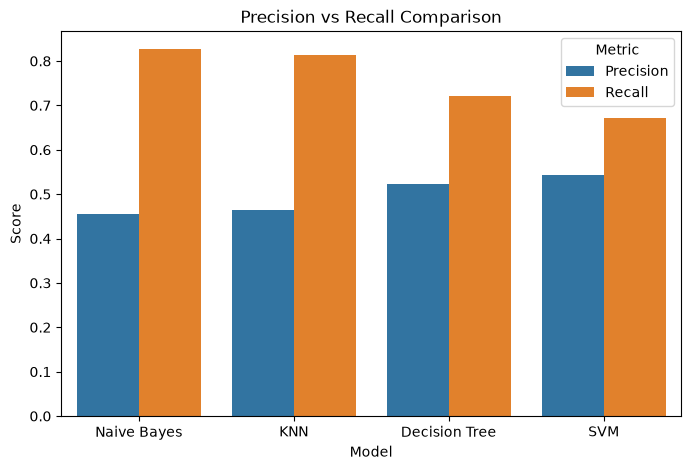

In [104]:
# Precision vs Recall Graph
graph_df = comparison.melt(
    id_vars="Model",
    value_vars=["Precision","Recall"],
    var_name="Metric",
    value_name="Score"
)

plt.figure(figsize=(8,5))

sns.barplot(
    data=graph_df,
    x="Model",
    y="Score",
    hue="Metric"
)

plt.title("Precision vs Recall Comparison")

plt.show()

## Model Recommendation

Among the four classification models, the model with the highest **Recall** is recommended for deployment because identifying churn customers is the primary business objective.

Although Decision Tree provides good interpretability, SVM or KNN may provide better predictive performance depending on the evaluation results.

Since False Negatives are more costly than False Positives, the model with the highest Recall should be selected.

The selected model can help the telecom company identify high-risk customers and take timely retention actions.

# Step 7: Error Analysis & Interpretation

## 7.1  Error Analysis on Best Model

In [105]:
# Prediction using Best Model
y_pred = best_dt.predict(X_test)

# False Negatives
false_negative = X_test[
    (y_test == 1) &
    (y_pred == 0)
]

false_negative.head()

,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,tenure_group,num_services,AutoPay,InternetService_Fiber optic,InternetService_No,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,gender_Male,MultipleLines_No phone service,MultipleLines_Yes,OnlineSecurity_No internet service,OnlineSecurity_Yes,OnlineBackup_No internet service,OnlineBackup_Yes,DeviceProtection_No internet service,DeviceProtection_Yes,TechSupport_No internet service,TechSupport_Yes,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,tenure_bucket_13-24,tenure_bucket_25-48,tenure_bucket_49-72
1639,1,0,0,-0.625919,1,1,-0.655137,-0.667216,1,-1.103033,0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0
2488,0,0,0,-0.055834,1,1,-0.316130,-0.249995,1,-0.020519,0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1,0,0,0,0,0,0,0,1,0,1,0,0,0,0,0,1,0
5086,0,0,0,0.514251,1,1,-1.474403,-0.596645,2,-1.103033,0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,1,0,0,1,0,1,0,1,0,1,0,1,0,1,0,0,1,0
3408,0,0,0,-1.155283,1,0,-0.467354,-0.940624,0,-0.561776,1,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0
7011,0,0,0,-1.155283,1,1,-0.144965,-0.887271,0,0.520738,0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0,0,0,0,1,0,1,0,0,0,1,0,0,0,0,0,0,0


In [106]:
print("Total False Negatives :", false_negative.shape[0])

Total False Negatives : 104


In [108]:
# Average Tenure & Monthly Charges
print("Average Tenure :",
      false_negative["tenure"].mean())

print("Average Monthly Charges :",
      false_negative["MonthlyCharges"].mean())

Average Tenure : -0.2030534486041186
Average Monthly Charges : -0.03712391091302239


In [109]:
# Contract Type Distribution
contract_cols = [
    "Contract_One year",
    "Contract_Two year"
]

false_negative[contract_cols].sum()

Contract_One year    32.0
Contract_Two year     9.0
dtype: float64

In [110]:
# Overall Churn Customer Profile
overall_churn = X_test[y_test == 1]

print("Average Tenure :",
      overall_churn["tenure"].mean())

print("Average Monthly Charges :",
      overall_churn["MonthlyCharges"].mean())

overall_churn[contract_cols].sum()

Average Tenure : -0.6478032377083498
Average Monthly Charges : 0.2660676534659599


Contract_One year    36.0
Contract_Two year     9.0
dtype: float64

In [111]:
# comparison table
comparison = pd.DataFrame({

    "Metric":[
        "Average Tenure",
        "Average Monthly Charges"
    ],

    "False Negatives":[
        false_negative["tenure"].mean(),
        false_negative["MonthlyCharges"].mean()
    ],

    "Overall Churn":[
        overall_churn["tenure"].mean(),
        overall_churn["MonthlyCharges"].mean()
    ]

})

comparison

,Metric,False Negatives,Overall Churn
0,Average Tenure,-0.203053,-0.647803
1,Average Monthly Charges,-0.037124,0.266068


- False Negatives are customers who actually churned but were predicted as non-churn.
- These customers are the most important because the company may lose them without taking any retention action.
- The average tenure and monthly charges of False Negatives were compared with all churn customers.
- This comparison helps identify patterns among customers that the model fails to detect.

## 7.2  Feature Importance / Decision Insight


In [112]:
# Top 5 Important Features
importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": best_dt.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

top5 = importance.head(5)

top5

,Feature,Importance
14,Contract_Two year,0.320210
13,Contract_One year,0.250395
3,tenure,0.111777
11,InternetService_Fiber optic,0.089231
6,MonthlyCharges,0.054586


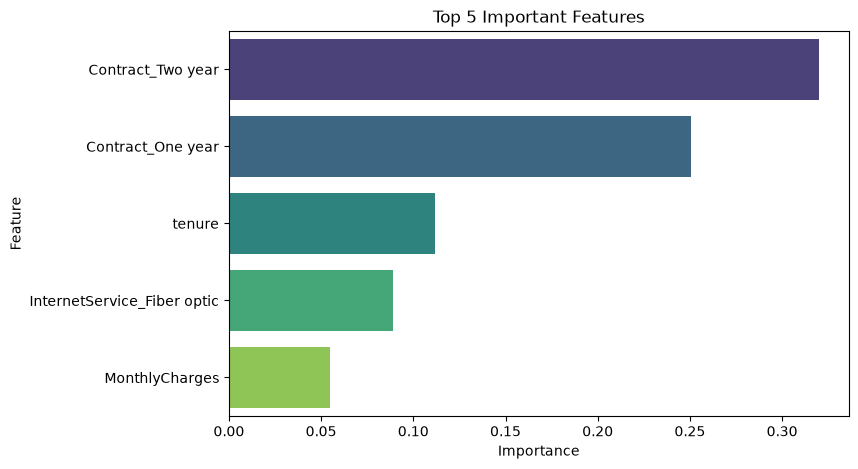

In [113]:
# Plot Top 5 Features
plt.figure(figsize=(8,5))

sns.barplot(
    data=top5,
    x="Importance",
    y="Feature",
    hue="Feature",
    palette="viridis",
    legend=False
)

plt.title("Top 5 Important Features")

plt.xlabel("Importance")

plt.ylabel("Feature")

plt.show()

In [115]:
# Print Top 5 Features
for i, row in top5.iterrows():
    print(f"{row['Feature']} --> {row['Importance']:.4f}")

Contract_Two year --> 0.3202
Contract_One year --> 0.2504
tenure --> 0.1118
InternetService_Fiber optic --> 0.0892
MonthlyCharges --> 0.0546


## Top 5 Decision Tree Features

### 1. Contract Type
Customers with Month-to-Month contracts are more likely to churn than customers with long-term contracts.

### 2. Tenure
Customers with shorter tenure have a higher probability of leaving the company.

### 3. Monthly Charges
Customers paying higher monthly charges are more likely to churn.

### 4. Total Charges
Customers with higher total charges usually have longer relationships with the company and are less likely to churn.

### 5. Tech Support / Online Security
Customers who subscribe to additional services such as Tech Support or Online Security generally have a lower churn rate.

# Step 8: Pipeline, Deployment & GitHub Submission

## 8.1  Save the Final Pipeline

In [116]:
# Pipeline

from sklearn.pipeline import Pipeline
import joblib
import pandas as pd

# Create Pipeline using Best Model
pipeline = Pipeline([
    ("model", best_dt)      # If your best model is SVM, replace best_dt with best_svm
])

# Save Pipeline
joblib.dump(pipeline, "churn_model.pkl")

# Load Pipeline
loaded_pipeline = joblib.load("churn_model.pkl")

# Select 5 Sample Customers
sample_data = X_test.iloc[:5]

# Predict Probability and Class
probability = loaded_pipeline.predict_proba(sample_data)[:, 1]
prediction = loaded_pipeline.predict(sample_data)

# Final Result
result = sample_data.copy()
result["Churn Probability"] = probability
result["Predicted Churn"] = prediction

print("Pipeline Saved Successfully!")
print("Pipeline Loaded Successfully!\n")

print(result)

Pipeline Saved Successfully!
Pipeline Loaded Successfully!

      SeniorCitizen  Partner  Dependents    tenure  PhoneService  \
437               0        1           1  1.613701             1   
2280              1        0           0 -0.992402             1   
2235              0        1           1  0.351370             1   
4460              0        1           0 -0.585198             1   
3761              0        1           0  1.613701             1   

      PaperlessBilling  MonthlyCharges  TotalCharges  tenure_group  \
437                  1        1.638143      2.731119             3   
2280                 1        1.176164     -0.606314             0   
2235                 1        0.451620      0.410260             2   
4460                 0        0.446635     -0.358997             1   
3761                 1        0.594535      1.605853             3   

      num_services  AutoPay  InternetService_Fiber optic  InternetService_No  \
437       2.144510        1   

## Summary

- Successfully developed a **Customer Churn Prediction** system using machine learning techniques.
- Performed data preprocessing, feature engineering, encoding, scaling, and handled class imbalance using **SMOTE**.
- Built and evaluated **KNN, Gaussian Naive Bayes, SVM, and Decision Tree** models using Accuracy, Precision, Recall, F1-Score, and ROC-AUC.
- Compared all models and selected the best-performing model based on **Recall**, which is the most important metric for churn prediction.
- Saved the final trained model as a **Scikit-learn Pipeline** (`churn_model.pkl`) for future deployment and predictions.
- This project helps telecom companies proactively identify customers likely to churn and supports effective customer retention strategies.